In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
data = pd.read_csv('Gaming_PC_Performance.csv')

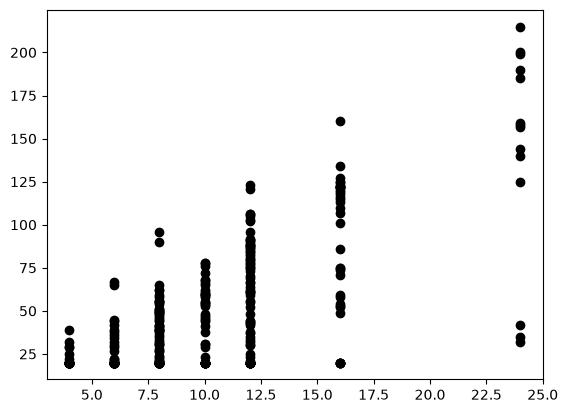

In [7]:
plt.scatter(data.GPU_VRAM_GB, data.AVG_FPS , color='black')

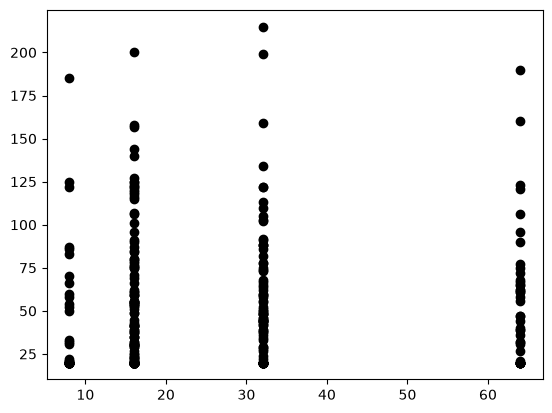

In [8]:
plt.scatter(data.RAM_GB, data.AVG_FPS , color='black')

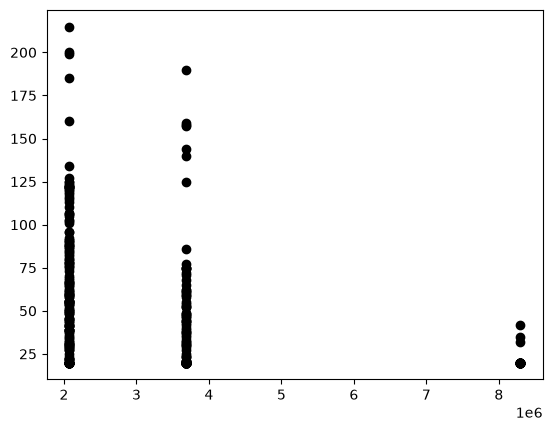

In [9]:
plt.scatter(data.RESOLUTION_PX, data.AVG_FPS , color='black')

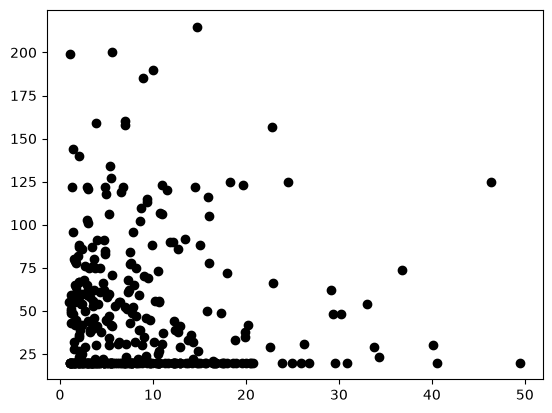

In [10]:
plt.scatter(data.HOURS_PLAYED_WEEK, data.AVG_FPS , color='black')

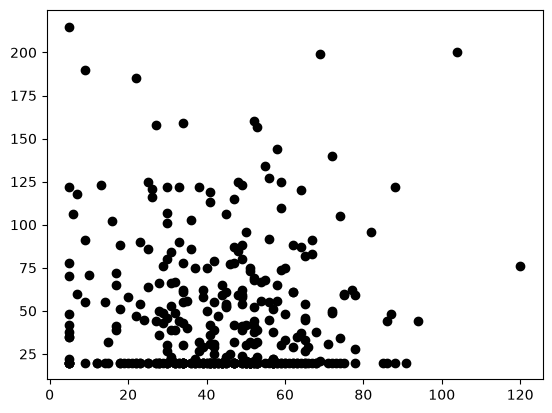

In [11]:
plt.scatter(data.PING_MS, data.AVG_FPS , color='black')

### answer:
###### the best x for the avg fps is GPU_VRAM_GB cause it has a better relationship with avg_fps than the rest of the options

In [23]:
print(f"""
gpu mean: {data.GPU_VRAM_GB.mean()}
avg fps mean: {data.AVG_FPS.mean()}
gpu std: {data.GPU_VRAM_GB.std()}
avg fps std: {data.AVG_FPS.std()}""")


gpu mean: 9.84
avg fps mean: 47.76571428571429
gpu std: 4.462848872335539
avg fps std: 37.530457108945335


###### avg fps has more std cause we have more gap between our data in avg fps

In [19]:
mask = np.random.rand(len(data)) < 0.8
train = data[mask]
test = data[~mask]

In [26]:
avgfpsAI = linear_model.LinearRegression()

In [27]:
train_x = np.asanyarray(train[['GPU_VRAM_GB']])
train_y = np.asanyarray(train[['AVG_FPS']])

In [28]:
avgfpsAI.fit(train_x,train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[6.39]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-15.29]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[75.23]


In [29]:
print(f"""
coefficient: {avgfpsAI.coef_}
intercept: {avgfpsAI.intercept_}""")


coefficient: [[6.38730621]]
intercept: [-15.28837775]


###### we got the coefficient and intercept so now we can complete our math formula (y = mx + b)

In [32]:
GpuVram = 12
answer = avgfpsAI.coef_[0][0] * GpuVram + avgfpsAI.intercept_[0]
print(f"your avg fps is gonna be: {round(answer,0)}")

your avg fps is gonna be: 61.0


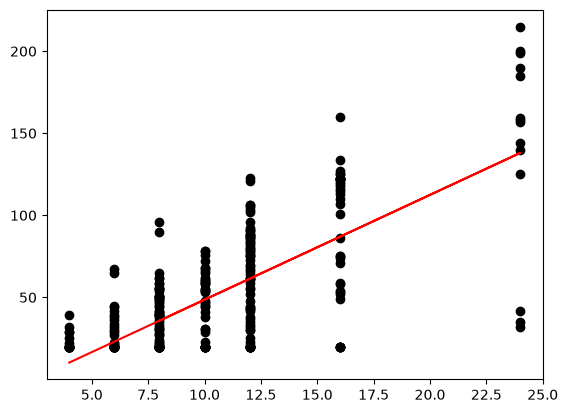

In [35]:
plt.scatter(data.GPU_VRAM_GB, data.AVG_FPS , color='black')
plt.plot(train_x,avgfpsAI.coef_[0][0] * train_x + avgfpsAI.intercept_[0],'r-')

In [36]:
test_x = np.asanyarray(test[['GPU_VRAM_GB']])
test_y = np.asanyarray(test[['AVG_FPS']])

In [37]:
test_y_out = avgfpsAI.predict(test_x)

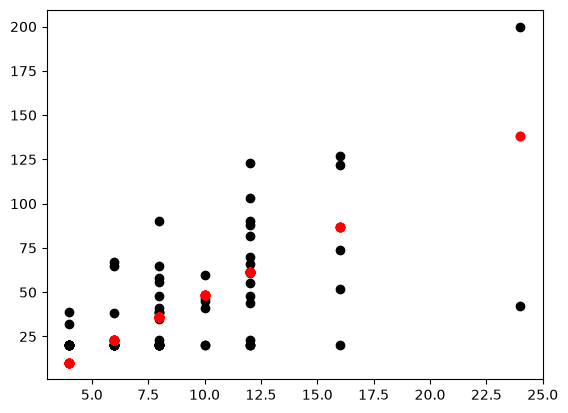

In [38]:
plt.scatter(test_x, test_y , color= 'black')
plt.scatter(test_x, test_y_out , color= 'red')

In [43]:
mae_abs = np.abs(test_y- test_y_out)
mae = np.mean(mae_abs)

squared = np.square(test_y - test_y_out)
mse = np.mean(squared)

r2_mean = np.mean(test_y)
ss_res = np.sum((test_y - test_y_out) ** 2)
ss_tot = np.sum((test_y - r2_mean) ** 2)

r2 = 1 - (ss_res / ss_tot)

In [44]:
print(f"""mae : {mae}
mse: {mse}
R2: {r2}""")

mae : 19.613663927021445
mse: 728.5326057505184
R2: 0.34823106158529293


###### r2 is genuinely cooked, we're fucked gng 

###### in the homework 3 we had r2: 0.93 that was genuinely good but know we have 0.3 and i think thats because we dont have a good realtionship between gpu vram and avg fps

In [47]:
mask2 = np.random.rand(len(data)) < 0.8
train2 = data[mask2]
test2 = data[~mask2]

weak_model = linear_model.LinearRegression()
train_x2 = np.asanyarray(train2[['PING_MS']])
train_y2 = np.asanyarray(train2[['AVG_FPS']])
weak_model.fit(train_x2, train_y2)

test_x2 = np.asanyarray(test2[['PING_MS']])
test_y2 = np.asanyarray(test2[['AVG_FPS']])
test_y2_out = weak_model.predict(test_x2)

mae2 = np.mean(np.abs(test_y2 - test_y2_out))
mse2 = np.mean((test_y2 - test_y2_out) ** 2)
r2_mean2 = np.mean(test_y2)
ss_res2 = np.sum((test_y2 - test_y2_out) ** 2)
ss_tot2 = np.sum((test_y2 - r2_mean2) ** 2)

r2_2 = 1 - (ss_res2 / ss_tot2)
print(f"MAE: {mae2}\nMSE: {mse2}\nR2: {r2_2}")

MAE: 32.16308117741295
MSE: 1591.0639642767499
R2: -0.03922580631281192
